In [1]:
from figures_functions import *
import cartopy
from matplotlib import colors
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Read results

In [2]:
# X-BASE (NEE)
MT_xb=xr.open_dataset('~/ResultsCS/MT_nee_Fluxcom_2001-2019.nc')
landarea=grid_cell_areas2(MT_xb) # in m2.
MT_xb=MT_xb.FLUXCOM
MT_xb["time"]=MT_xb["time"].astype("datetime64[ns]")
CS_xb=xr.open_dataset('~/ResultsCS/CS_nee_Fluxcom_2001-2019.nc')
CS_xb=CS_xb.FLUXCOM#/1e+4 # to ha
# mod='FLUXCOM-X'
# mod2='Fluxcom'
# var='NEE'

# CAMS (NBP)
MT_cm=xr.open_dataset('~/ResultsCS/MT_nbp_CAMS_2001-2019.nc')
landarea=grid_cell_areas2(MT_cm) # in m2.
MT_cm=MT_cm.CAMS
MT_cm["time"]=MT_cm["time"].astype("datetime64[ns]")
CS_cm=xr.open_dataset('~/ResultsCS/CS_nbp_CAMS_2001-2019.nc')
CS_cm=CS_cm.CAMS#/1e+4 # from [kgC m-2 yr-2] to [kgC ha yr-2] 
# mod='CAMS'

# CarboScope (NBP)
MT_cc=xr.open_dataset('~/ResultsCS/MT_nbp_CarboScope_2001-2019.nc')
landarea=grid_cell_areas2(MT_cc) # in m2.
MT_cc["time"]=MT_cc["time"].astype("datetime64[ns]")
CS_cc=xr.open_dataset('~/ResultsCS/CS_nbp_CarboScope_2001-2019.nc')
CS_cc=CS_cc.CarboScope#/1e+4 # from [kgC m-2 yr-2] to [KgC ha yr-2] 


/home/_ehoyos/anaconda3/lib/python3.9/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/_ehoyos/anaconda3/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


## Maps and latitudinal variations

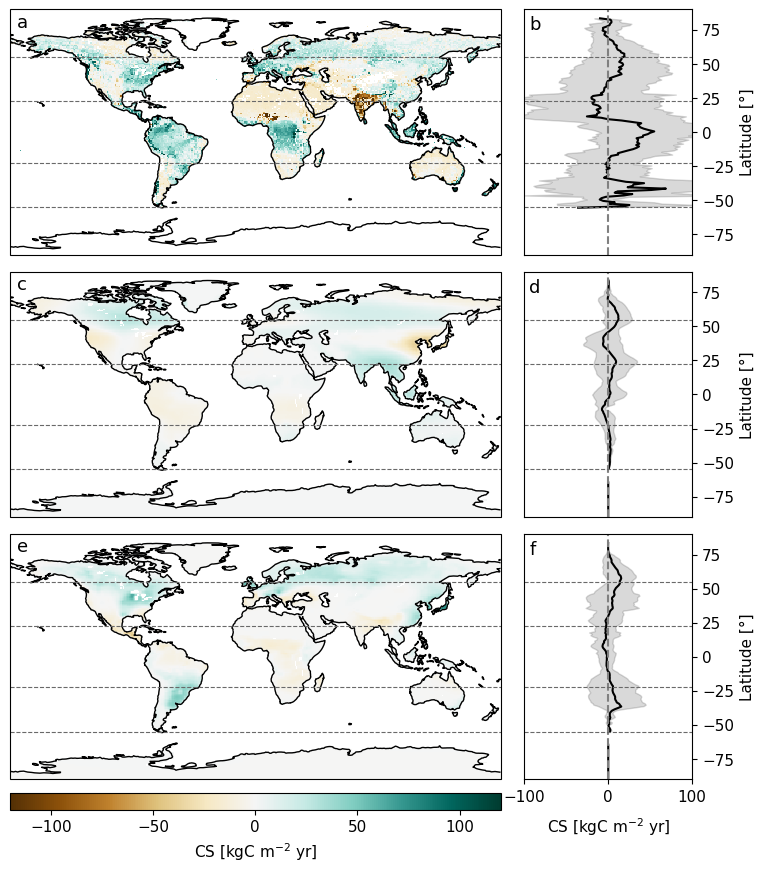

In [4]:
cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
colors2=np.vstack((color1,color2))

vmin=-120; vmax=120; nf=21
vmin2=-50; vmax2=50
levels=np.linspace(vmin,vmax,nf)
divnorm=colors.TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax)
 
plt.rcParams.update({'font.size':11})
fig3=plt.figure(figsize=(9,10))
grid=plt.GridSpec(6,4,wspace=0.05,hspace=0.15)
ax1=plt.subplot(grid[0:2,0:3],projection=cartopy.crs.PlateCarree())
ax2=plt.subplot(grid[0:2,3:])#,xticklabels=[])#,sharey=ax1)
ax3=plt.subplot(grid[2:4,0:3],projection=cartopy.crs.PlateCarree())
ax4=plt.subplot(grid[2:4,3:])#,xticklabels=[])#,sharey=ax1)
ax5=plt.subplot(grid[4:6,0:3],projection=cartopy.crs.PlateCarree())
ax6=plt.subplot(grid[4:6,3:])#,xticklabels=[])#,sharey=ax1)

# # X-BASE
CS=CS_xb
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax1.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax1.coastlines()
ax1.set_xlabel(''); ax1.set_ylabel('')
ax1.set_title('')
ax1.set_ylim(-90,90)
ax1.set_yticks([])
ax1.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax1.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax1.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax1.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax2,y='lat',color='black')
ax2.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax2.yaxis.tick_right() 
ax2.set_ylabel('Latitude [°]')
ax2.yaxis.set_label_position("right")
ax2.set_xlabel(" ")
ax2.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax2.set_title('')
ax2.set_ylim(-90,90)
ax2.set_xlim(-100,100)
ax2.xaxis.set_visible(False)
ax2.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax2.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax2.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax2.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)


# # CarboScope
CS=CS_cc
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax3.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax3.coastlines()
ax3.set_xlabel(''); ax3.set_ylabel('')
ax3.set_title('')
ax3.set_ylim(-90,90)
ax3.set_yticks([])
ax3.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax3.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax3.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax3.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax4,y='lat',color='black')
ax4.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax4.yaxis.tick_right() 
ax4.set_ylabel('Latitude [°]')
ax4.yaxis.set_label_position("right")
ax4.set_xlabel(" ")
ax4.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax4.set_title('')
ax4.set_ylim(-90,90)
ax4.set_xlim(-100,100)
ax4.xaxis.set_visible(False)
ax4.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax4.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax4.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax4.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

# # CAMS
CS=CS_cm
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax5.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax5.coastlines()
ax5.set_xlabel(''); ax3.set_ylabel('')
ax5.set_title('')
ax5.set_ylim(-90,90)
ax5.set_yticks([])
ax5.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax5.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax5.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax5.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax6,y='lat',color='black')
ax6.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax6.yaxis.tick_right() 
ax6.set_ylabel('Latitude [°]')
ax6.yaxis.set_label_position("right")
ax6.set_xlabel(" ")
ax6.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax6.set_title('')
ax6.set_ylim(-90,90)
ax6.set_xlim(-100,100)
ax6.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax6.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax6.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax6.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)
ax6.set_xlabel(r"CS [kgC m$^{-2}$ yr]",labelpad=8)

# Legend bar
axins=inset_axes(ax5,width="100%",height="7%",loc='lower center',borderpad=-2)
fig3.colorbar(csp,cax=axins,orientation="horizontal",label=r"CS [kgC m$^{-2}$ yr]")

# Panels
ax1.text(-175, 77, 'a',fontsize=13)
ax2.text(-94,75,'b',fontsize=13)
ax3.text(-175, 77, 'c',fontsize=13)
ax4.text(-94,75,'d',fontsize=13)
ax5.text(-175, 77, 'e',fontsize=13)
ax6.text(-94,75,'f',fontsize=13)

fig3.savefig('/home/_ehoyos/cmip6stop/CS/Figures/data_products_CS_map_latitude_2001-2010.pdf',bbox_inches="tight")

## Maps in two figures

### NEP

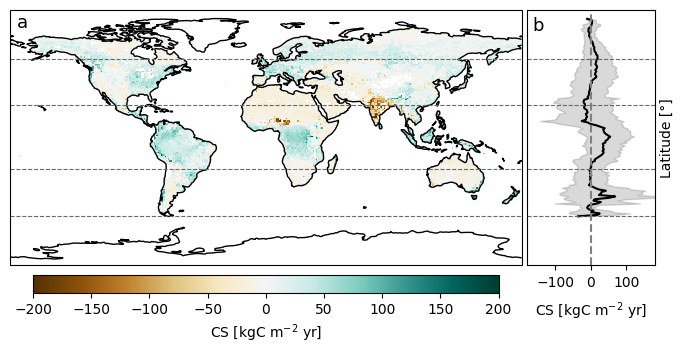

In [10]:
cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
colors2=np.vstack((color1,color2))
vmin=-200; vmax=200; nf=21
vmin2=-50; vmax2=50
levels=np.linspace(vmin,vmax,nf)
divnorm=colors.TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax)

plt.rcParams.update({'font.size':10})
fig4 = plt.figure(figsize=(9,10))
grid = plt.GridSpec(6, 4, wspace=0.01, hspace=0.01)
ax1 = plt.subplot(grid[0:2, :], projection=ccrs.PlateCarree())
ax1._autoscaleXon = False 
ax1._autoscaleYon = False
ax2 = ax1.inset_axes([1.01, 0, 0.25, 1], sharey=ax1) 

# # X-BASE
CS=CS_xb
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax1.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax1.coastlines()
ax1.set_xlabel(''); ax1.set_ylabel('')
ax1.set_title('')
ax1.set_ylim(-90,90)
ax1.set_yticks([])
ax1.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax1.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax1.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax1.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax2,y='lat',color='black')
ax2.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax2.yaxis.tick_right() 
ax2.set_ylabel('Latitude [°]')
ax2.yaxis.set_label_position("right")
ax2.set_xlabel(" ")
ax2.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax2.set_title('')
ax2.set_ylim(-90,90)
ax2.set_xlim(-180,180)
#ax2.xaxis.set_visible(False)
ax2.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax2.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax2.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax2.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)
ax2.set_xlabel(r"CS [kgC m$^{-2}$ yr]",labelpad=8)

# Legend bar
axins=inset_axes(ax1,width="91%",height="7%",loc='lower center',borderpad=-2)
fig4.colorbar(csp,cax=axins,orientation="horizontal",label=r"CS [kgC m$^{-2}$ yr]")

# Panels
ax1.text(-175, 77, 'a',fontsize=13)
ax2.text(-165,75,'b',fontsize=13)
fig4.savefig('/home/_ehoyos/cmip6stop/CS/Figures/CS_map_latitude_2001-2010_NEP.pdf',bbox_inches="tight")

### NBP

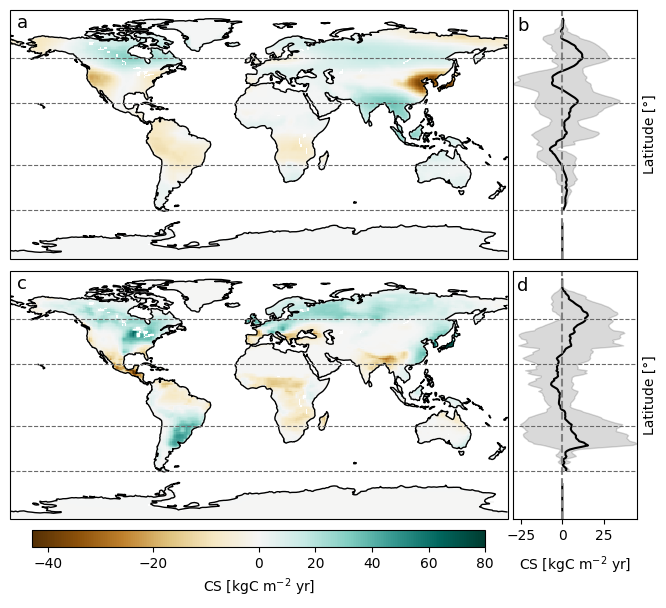

In [9]:
cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
colors2=np.vstack((color1,color2))

vmin=-43; vmax=80; nf=21
vmin2=-30; vmax2=45
levels=np.linspace(vmin,vmax,nf)
divnorm=colors.TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax)
grid = plt.GridSpec(6, 4, wspace=0.1, hspace=0.1)
plt.rcParams.update({'font.size':10})
fig5=plt.figure(figsize=(9,10))

ax3=plt.subplot(grid[0:2,0:3],projection=cartopy.crs.PlateCarree())
ax3._autoscaleXon = False ; ax3._autoscaleYon = False
ax4= ax3.inset_axes([1.01, 0, 0.25, 1], sharey=ax3)

ax5=plt.subplot(grid[2:4,0:3],projection=cartopy.crs.PlateCarree())
ax5._autoscaleXon = False ; ax5._autoscaleYon = False
ax6=ax5.inset_axes([1.01, 0, 0.25, 1], sharey=ax5)

# # CarboScope
CS=CS_cc
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax3.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax3.coastlines()
ax3.set_xlabel(''); ax3.set_ylabel('')
ax3.set_title('')
ax3.set_ylim(-90,90)
ax3.set_yticks([])
ax3.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax3.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax3.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax3.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax4,y='lat',color='black')
ax4.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax4.yaxis.tick_right() 
ax4.set_ylabel('Latitude [°]')
ax4.yaxis.set_label_position("right")
ax4.set_xlabel(" ")
ax4.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax4.set_title('')
ax4.set_ylim(-90,90)
ax4.set_xlim(vmin2,vmax2)
ax4.xaxis.set_visible(False)
ax4.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax4.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax4.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax4.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

# # CAMS
CS=CS_cm
CS.coords['lon']=(CS.coords['lon']+180)%360-180
CS=CS.sortby(CS.lon)

csp=ax5.pcolormesh(CS.lon,CS.lat,CS,cmap="BrBG",norm=divnorm,transform=cartopy.crs.PlateCarree())
ax5.coastlines()
ax5.set_xlabel(''); ax3.set_ylabel('')
ax5.set_title('')
ax5.set_ylim(-90,90)
ax5.set_yticks([])
ax5.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax5.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax5.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax5.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)

CS.mean(["lon"]).plot(ax=ax6,y='lat',color='black')
ax6.fill_betweenx(CS.lat,CS.mean(["lon"])-2*CS.std(["lon"]),CS.mean(["lon"])+2*CS.std(["lon"]),color='black',alpha=0.15)
             
ax6.yaxis.tick_right() 
ax6.set_ylabel('Latitude [°]')
ax6.yaxis.set_label_position("right")
ax6.set_xlabel(" ")
ax6.axvline(x=0,color='gray',ls='--',linewidth=1.5)
ax6.set_title('')
ax6.set_ylim(-90,90)
ax6.set_xlim(vmin2,vmax2)
ax6.axhline(y=22.5,color='dimgray',ls='--',linewidth=0.8); ax6.axhline(y=-22.5,color='dimgray',ls='--',linewidth=0.8)
ax6.axhline(y=55,color='dimgray',ls='--',linewidth=0.8);ax6.axhline(y=-55,color='dimgray',ls='--',linewidth=0.8)
ax6.set_xlabel(r"CS [kgC m$^{-2}$ yr]",labelpad=8)

# Legend bar
axins=inset_axes(ax5,width="91%",height="7%",loc='lower center',borderpad=-2)
fig5.colorbar(csp,cax=axins,orientation="horizontal",label=r"CS [kgC m$^{-2}$ yr]")

# Panels
ax3.text(-175, 77, 'a',fontsize=13)
ax4.text(-27,75,'b',fontsize=13)
ax5.text(-175, 77, 'c',fontsize=13)
ax6.text(-27,75,'d',fontsize=13)

fig5.savefig('/home/_ehoyos/cmip6stop/CS/Figures/CS_map_latitude_2001-2010_NBP.pdf',bbox_inches="tight")

## Temporal variations by latitude ranges

#### Save info in .csv

In [165]:
# # # CMIP6
gc.collect()

prod=['X-BASE','CarboScope','CAMS']
titles=['Global','Tropics','Mid latitudes','High latitudes']
tit=['glob','trop','mid','high']

for i in range(len(prod)):
# for i in range(1):
    if i==0:Mt=MT_xb
    if i==1:Mt=MT_cc
    if i==2:Mt=MT_cm
    nt=len(Mt.time) # time length.
    for k in range(len(titles)):#len(titles) # spatial divisions.
        if k==0:Mts=Mt # Global
        if k==1:mask=((Mt.lat <= 22.5)&(Mt.lat >= -22.5)) # Tropics
        if k==2:
            mask1=(Mt.lat > 22.5)&(Mt.lat < 55.0) # mid latitudes.
            mask2=(Mt.lat < -22.5) # mid latitudes.
        if k==3:mask=(Mt.lat >= 55.0) # high latitudes
        
        if k!=0: Mts=Mt.where(mask,drop=True)
#         #Mts.sum("lon").sum("lat")
# Time series    
        if k==2:
            Mts=Mt
            css_cum=Mts.cumulative_integrate("time",datetime_unit='D')/30.4/12
            cssz1=css_cum.where(mask1,drop=True);cssz2=css_cum.where(mask2,drop=True)
            css_cumxy=calc_spatial_integral(cssz1)+calc_spatial_integral(cssz2) 
            Mts_xy=calc_spatial_integral(Mts.where(mask1,drop=True))+calc_spatial_integral(Mts.where(mask2,drop=True))
        else:
            css_cum=Mts.cumulative_integrate("time",datetime_unit='D')/30.4/12
            css_cumxy=calc_spatial_integral(css_cum)#css_cum.sum(["lon"]).sum(["lat"])
            Mts_xy=calc_spatial_integral(Mts)
        CSl=css_cumxy
        dfCS=CSl.to_dataframe()
        dfCS.to_csv('~/ResultsCS/Lat/2001-2019/'+prod[i]+'_cs_cum_lat_'+tit[k]+'_'+'2001-2019.csv')

### X-BASE

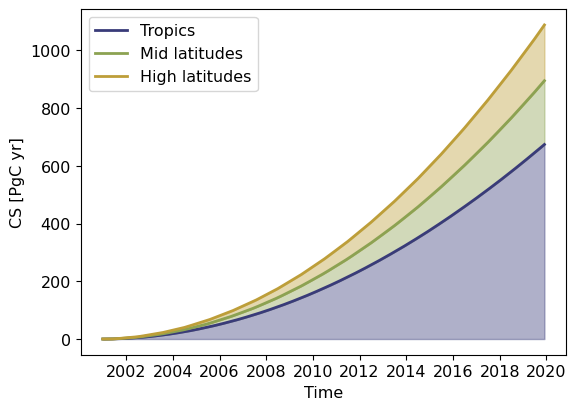

In [144]:
cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
plt.rcParams.update({'font.size':11.5})
tit=['glob','trop','mid','high']
titles=['Global','Tropics','Mid latitudes','High latitudes']
ens=np.zeros(len(titles))

fig4=plt.subplots(ncols=1,nrows=1,figsize=[4*np.sqrt(2),8/2],constrained_layout=True)
 
for k in range(1,len(titles)): # spatial divisions.
#for k in range(3,4): # spatial divisions.
    CSt=pd.read_csv('~/ResultsCS/Lat/2001-2019/X-BASE_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
    CS=CSt
    CS["time"]=CS["time"].astype("datetime64[ns]")
    if k==1: b=np.zeros(len(CS.time)); b2=0
    plt.plot(CS.time.values,(CS[CS.columns[1]].values+b)/1e+12,color=colorv[k-1],linewidth=2,label=titles[k])
    plt.fill_between(CS.time.values,b/1e+12,(CS[CS.columns[1]].values+b)/1e+12,color=colorv[k-1],alpha=0.4)
    b=b+CS[CS.columns[1]].values
        
plt.legend()
plt.xlabel("Time")
plt.ylabel("CS [PgC yr]")
# plt.ticklabel_format(axis='y', style='',scilimits=[10,200])

plt.savefig('/home/_ehoyos/cmip6stop/CS/Figures/X-BASE_NEE_CS_time_final_res.pdf',bbox_inches="tight")   

### CarboScope and CAMS

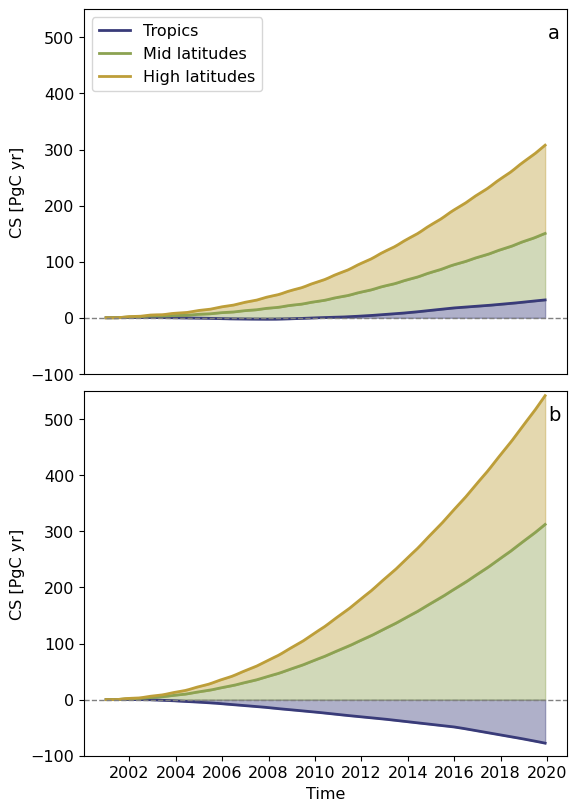

In [52]:
cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
plt.rcParams.update({'font.size':11.5})
tit=['glob','trop','mid','high']
titles=['Global','Tropics','Mid latitudes','High latitudes']
ens=np.zeros(len(titles))

fig4,ax=plt.subplots(ncols=1,nrows=2,figsize=[4*np.sqrt(2),8],constrained_layout=True)
titles=['Global','Tropics','Mid latitudes','High latitudes']

for i in range(2):
    for k in range(1,len(titles)): # spatial divisions.
    #for k in range(1,2): # spatial divisions.
            
        if i==0:CS=pd.read_csv('~/ResultsCS/Lat/2001-2019/CarboScope_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
        if i==1:CS=pd.read_csv('~/ResultsCS/Lat/2001-2019/CAMS_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
        CS["time"]=CS["time"].astype("datetime64[ns]")

        if k==1: b=np.zeros(len(CS.time)); b2=0
        ax[i].plot(CS.time.values,(CS[CS.columns[1]].values+b)/1e+12,color=colorv[k-1],linewidth=2,label=titles[k])
        ax[i].fill_between(CS.time.values,b/1e+12,(CS[CS.columns[1]].values+b)/1e+12,color=colorv[k-1],alpha=0.4)
        b=b+CS[CS.columns[1]].values
        b[b<0]=0
    ax[i].set_ylim(-100,550)
    

ax[0].axhline(y=0,color='gray',ls='--',linewidth=1)    
ax[0].legend()
ax[0].set_xticks([]) 
ax[1].set_xlabel("Time")
ax[0].set_ylabel("CS [PgC yr]")

ax[1].axhline(y=0,color='gray',ls='--',linewidth=1)
ax[1].set_ylabel("CS [PgC yr]")

ax[0].text(0.96,0.92,'a',transform=ax[0].transAxes,fontsize=14)  
ax[1].text(0.96,0.92,'b',transform=ax[1].transAxes,fontsize=14)



fig4.savefig('/home/_ehoyos/cmip6stop/CS/Figures/CAMS_CARBOSCOPE_NBP_CS_time_final_res.pdf',bbox_inches="tight")

## Comparison single and double integral

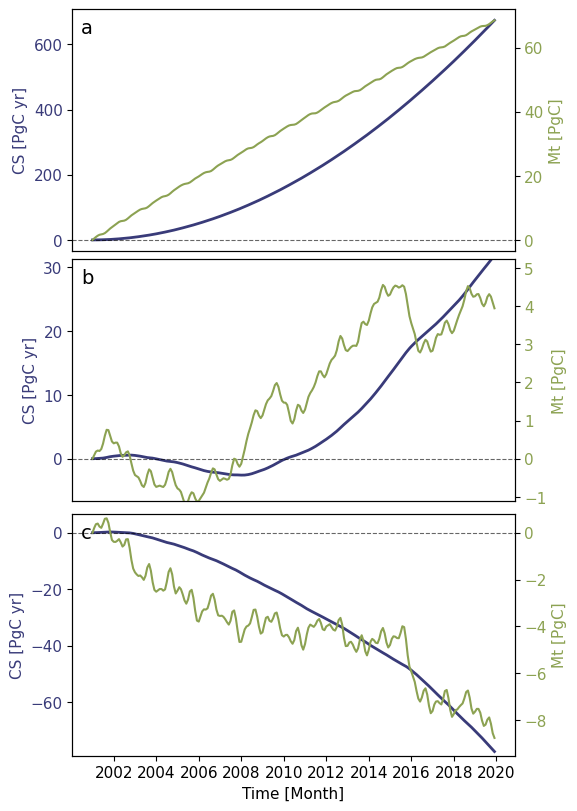

In [188]:
plt.rcParams.update({'font.size':11})
cmap=plt.cm.tab20b
colorv=cmap([0,0.25,0.45])
tit=['glob','trop','mid','high']
bb=['a','b','c']
fig5,ax=plt.subplots(ncols=1,nrows=3,figsize=[4*np.sqrt(2),8],constrained_layout=True)
k=1
for i in range(3):
# files
    if i==0:
        CS=pd.read_csv('~/ResultsCS/Lat/2001-2019/X-BASE_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
        Mt=xr.open_dataset('~/ResultsCS/MT_nee_Fluxcom_2001-2019.nc')   
    if i==1:
        CS=pd.read_csv('~/ResultsCS/Lat/2001-2019/CarboScope_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
        Mt=xr.open_dataset('~/ResultsCS/MT_nbp_CarboScope_2001-2019.nc')  
    if i==2:
        CS=pd.read_csv('~/ResultsCS/Lat/2001-2019/CAMS_cs_cum_lat_'+tit[k]+'_2001-2019.csv')
        Mt=xr.open_dataset('~/ResultsCS/MT_nbp_CAMS_2001-2019.nc') 
    CS["time"]=CS["time"].astype("datetime64[ns]")
    
#Mt spatial integration   
    if k==0:Mts=Mt # Global
    if k==1:mask=((Mt.lat <= 22.5)&(Mt.lat >= -22.5)) # Tropics
    if k==2:
        mask1=(Mt.lat > 22.5)&(Mt.lat < 55.0) # mid latitudes.
        mask2=(Mt.lat < -22.5) # mid latitudes.
    if k==3:mask=(Mt.lat >= 55.0) # high latitudes
    if k!=0: Mts=Mt.where(mask,drop=True)
    Mts_xy=calc_spatial_integral(Mts)    

    ax[i].plot(CS.time.values,(CS[CS.columns[1]].values)/1e+12,linewidth=2,color=colorv[0])
    ax[i].set_ylabel('CS [PgC yr]',color=colorv[0])
    ax[i].tick_params(axis='y',labelcolor=colorv[0])
    ax2=ax[i].twinx()
    
    ax2.plot(Mts_xy.time.values,Mts_xy[list(Mts_xy.data_vars)[0]]/1e12,color=colorv[1])
    ax2.set_ylabel('Mt [PgC]', color=colorv[1])
    ax2.tick_params(axis='y',labelcolor=colorv[1])
    
 # OBTENER límites actuales DESPUÉS de plot
    y1_min, y1_max = ax[i].get_ylim()
    y2_min, y2_max = ax2.get_ylim()

# Calcular POSICIÓN normalizada (0-1) donde está el cero en cada eje
    pos1 = (0 - y1_min) / (y1_max - y1_min)
    pos2 = (0 - y2_min) / (y2_max - y2_min)

# USAR LA POSICIÓN PROMEDIO para alinear perfectamente
    zero_pos = (pos1 + pos2) / 2

# RECONSTRUIR límites manteniendo rangos originales pero moviendo cero
    range1 = y1_max - y1_min
    range2 = y2_max - y2_min

    ax[i].set_ylim(0 - zero_pos * range1, 0 + (1-zero_pos) * range1)
    ax2.set_ylim(0 - zero_pos * range2, 0 + (1-zero_pos) * range2)
    ax[i].axhline(0, color='k', lw=0.8, alpha=0.6,ls='--')
    
    ax[i].text(0.02,0.9,bb[i],transform=ax[i].transAxes,fontsize=14)


ax[0].set_xticks([]); ax[1].set_xticks([])  
ax[-1].set_xlabel('Time [Month]')
plt.show()
fig5.savefig('/home/_ehoyos/cmip6stop/CS/Figures/data_products_comparison_CS_Mt_'+tit[k]+'.pdf',bbox_inches="tight")